
# Sentiment Analysis

**Data source:** http://snap.stanford.edu/data/amazon/productGraph/categoryFiles/reviews_Digital_Music_5.json.gz



In [1]:

# Import thư viện
import os, gzip, json, math, urllib.request, shutil
from pathlib import Path
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


### 1. Load data into a pandas DataFrame

In [2]:

# Tải dataset
url = 'http://snap.stanford.edu/data/amazon/productGraph/categoryFiles/reviews_Digital_Music_5.json.gz'
out_path = Path('./data/reviews_Digital_Music_5.json.gz')
if not out_path.exists():
    print('Tải dataset...')
    try:
        urllib.request.urlretrieve(url, out_path)
        print('Đã tải về:', out_path)
    except Exception as e:
        print('Tải về thất bại — Exception:', e)
else:
    print('Dataset đã tồn tại:', out_path)


Tải dataset...
Đã tải về: data\reviews_Digital_Music_5.json.gz


In [3]:

# Load dữ liệu vào DataFrame
def load_amazon_json_gz(path, n_rows=None):
    records = []
    with gzip.open(path, 'rt', encoding='utf-8') as f:
        for i, line in enumerate(f):
            if n_rows and i>=n_rows:
                break
            records.append(json.loads(line))
    return pd.DataFrame(records)

# Load data
if out_path.exists():
    print('Loading')
    df = load_amazon_json_gz(out_path, n_rows=None)
    print('Đã tải xong', len(df), 'rows. Columns:', df.columns.tolist())
    display(df.head(3))
else:
    print('Không tìm thấy tệp dữ liệu.')


Loading
Đã tải xong 64706 rows. Columns: ['reviewerID', 'asin', 'reviewerName', 'helpful', 'reviewText', 'overall', 'summary', 'unixReviewTime', 'reviewTime']


,reviewerID,asin,reviewerName,helpful,reviewText,overall,summary,unixReviewTime,reviewTime
0,A3EBHHCZO6V2A4,5555991584,"Amaranth ""music fan""","[3, 3]","It's hard to believe ""Memory of Trees"" came ou...",5.0,Enya's last great album,1158019200,"09 12, 2006"
1,AZPWAXJG9OJXV,5555991584,bethtexas,"[0, 0]","A clasically-styled and introverted album, Mem...",5.0,Enya at her most elegant,991526400,"06 3, 2001"
2,A38IRL0X2T4DPF,5555991584,bob turnley,"[2, 2]",I never thought Enya would reach the sublime h...,5.0,The best so far,1058140800,"07 14, 2003"


### 2. Preprocessing & Vectorizing 

In [4]:

# Tiền xử lý dữ liệu
# Giữ lại các cột cần thiết và xử lý giá trị thiếu
print('Columns available (sample):', df.columns.tolist())
df = df[['reviewerID','asin','overall','reviewText','summary','unixReviewTime']].copy()
df['reviewText'] = df['reviewText'].fillna('')
df['summary'] = df['summary'].fillna('')

# Tạo nhãn cảm xúc nhị phân: 1 cho tích cực (đánh giá >=4), 0 cho tiêu cực (đánh giá <=2). Bỏ giá trị (3) ở giữa
df['sentiment_binary'] = df['overall'].apply(lambda x: 1 if x>=4 else (0 if x<=2 else 2))

print('Đếm dựa theo rating:')
print(df['overall'].value_counts().sort_index())

print('\nĐếm theo nhãn nhị phân:')
print(df['sentiment_binary'].value_counts())

# Loại bỏ các dòng có nhãn trung lập (rating=3)
df_bin = df[df['sentiment_binary']!=2].copy()
df_bin['y'] = df_bin['sentiment_binary']

print('\nSau khi loại bỏ các dòng trung lập, kích thước tập dữ liệu:', len(df_bin))
display(df_bin.head(2))


Columns available (sample): ['reviewerID', 'asin', 'reviewerName', 'helpful', 'reviewText', 'overall', 'summary', 'unixReviewTime', 'reviewTime']
Đếm dựa theo rating:
overall
1.0     2791
2.0     3010
3.0     6789
4.0    16536
5.0    35580
Name: count, dtype: int64

Đếm theo nhãn nhị phân:
sentiment_binary
1    52116
2     6789
0     5801
Name: count, dtype: int64

Sau khi loại bỏ các dòng trung lập, kích thước tập dữ liệu: 57917


,reviewerID,asin,overall,reviewText,summary,unixReviewTime,sentiment_binary,y
0,A3EBHHCZO6V2A4,5555991584,5.0,"It's hard to believe ""Memory of Trees"" came ou...",Enya's last great album,1158019200,1,1
1,AZPWAXJG9OJXV,5555991584,5.0,"A clasically-styled and introverted album, Mem...",Enya at her most elegant,991526400,1,1


In [5]:

# Tiền xử lý văn bản và vector hóa TF-IDF
import re
def preprocess_text(s):
    s = s.lower()
    s = re.sub(r'http\S+', ' ', s)
    s = re.sub(r'[^a-z0-9\s]', ' ', s)
    s = re.sub(r'\s+', ' ', s).strip()
    return s

df_bin['text'] = (df_bin['reviewText'] + ' ' + df_bin['summary']).astype(str).apply(preprocess_text)

# Vectorize với TF-IDF
vectorizer = TfidfVectorizer(max_features=20000, ngram_range=(1,2), stop_words='english')
X = vectorizer.fit_transform(df_bin['text'])
y = df_bin['y'].values

print('Kích thước ma trận TF-IDF:', X.shape)


Kích thước ma trận TF-IDF: (57917, 20000)


### 3. Building Model
### 4. Evaluation

In [6]:

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)
print('Train size:', X_train.shape, 'Test size:', X_test.shape)


Train size: (46333, 20000) Test size: (11584, 20000)


In [7]:

# Logistic Regression
lr = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
lr.fit(X_train, y_train)
y_pred = lr.predict(X_test)

acc = accuracy_score(y_test, y_pred)
prec, rec, f1, _ = precision_recall_fscore_support(y_test, y_pred, average='binary')
print('Logistic Regression — Accuracy: {:.4f}, Precision: {:.4f}, Recall: {:.4f}, F1: {:.4f}'.format(acc, prec, rec, f1))
print('\nReport:\n', classification_report(y_test, y_pred, target_names=['negative','positive']))


Logistic Regression — Accuracy: 0.9422, Precision: 0.9434, Recall: 0.9955, F1: 0.9688

Report:
               precision    recall  f1-score   support

    negative       0.92      0.46      0.62      1160
    positive       0.94      1.00      0.97     10424

    accuracy                           0.94     11584
   macro avg       0.93      0.73      0.79     11584
weighted avg       0.94      0.94      0.93     11584



In [8]:

# Multinomial Naive Bayes
nb = MultinomialNB()
nb.fit(X_train, y_train)
y_pred_nb = nb.predict(X_test)
print('MultinomialNB Accuracy:', accuracy_score(y_test, y_pred_nb))


MultinomialNB Accuracy: 0.9175587016574586


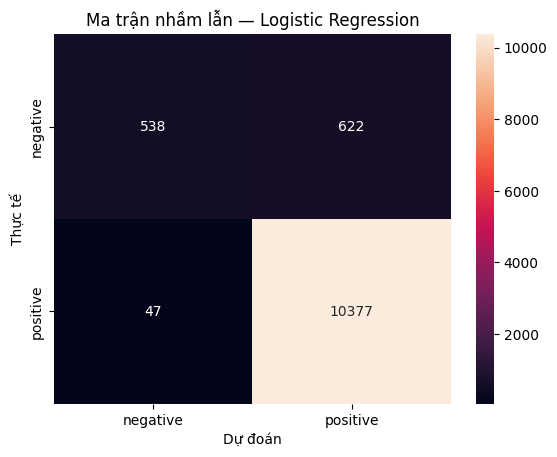

In [9]:

# Ma trận nhầm lẫn cho Logistic Regression
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', xticklabels=['negative','positive'], yticklabels=['negative','positive'])
plt.title('Ma trận nhầm lẫn — Logistic Regression')
plt.xlabel('Dự đoán')
plt.ylabel('Thực tế')
plt.show()


In [10]:

# Đánh giá đa lớp (1-5)
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_multiclass = le.fit_transform(df['overall'].values)
X_all = vectorizer.transform(df['reviewText'].fillna('') + ' ' + df['summary'].fillna(''))
X_tr, X_te, y_tr, y_te = train_test_split(X_all, y_multiclass, test_size=0.2, random_state=RANDOM_STATE, stratify=y_multiclass)
clf = LogisticRegression(max_iter=1000, multi_class='multinomial', random_state=RANDOM_STATE)
clf.fit(X_tr, y_tr)
yp = clf.predict(X_te)
print('Multiclass accuracy (1-5):', accuracy_score(y_te, yp))
print('\nReport (multiclass):\n', classification_report(y_te, yp, target_names=[str(x) for x in le.classes_]))


c:\Users\user\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Multiclass accuracy (1-5): 0.6512131046206151

Report (multiclass):
               precision    recall  f1-score   support

         1.0       0.73      0.50      0.59       558
         2.0       0.47      0.14      0.22       602
         3.0       0.46      0.27      0.34      1358
         4.0       0.50      0.39      0.44      3307
         5.0       0.71      0.90      0.80      7117

    accuracy                           0.65     12942
   macro avg       0.57      0.44      0.48     12942
weighted avg       0.62      0.65      0.62     12942

